# Urban VLM — UrbanVLM Pipeline on Place Pulse 2.0

**Pipeline:**
1. Pairwise votes → Q-scores per image per attribute
2. Caption generation using LLaVA-1.5
3. Dual-modality CLIP encoding (image + caption)
4. Random Forest regression to predict perception scores
5. Evaluation with MAE and R²

**Based on:** UrbanVLM (IJCNN 2025) — simplified version without contrastive learning

**Hardware:** A100 80GB (enable High RAM slider)

---
### Key Design Decision
Q-scores are computed **per attribute** separately — mixing attributes would give meaningless scores.
Start with `ATTRIBUTE_NAME = 'safer'` and `N_SAMPLES = 100` for a quick test.

---
## Section 1: Install and Imports

In [ ]:
!pip install -q transformers>=4.40.0 accelerate Pillow tqdm pandas scikit-learn

In [ ]:
import torch
import pandas as pd
import numpy as np
import os
import re
import random
from PIL import Image as PILImage
from tqdm import tqdm
from collections import defaultdict

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

GPU available: True
GPU name: NVIDIA A100-SXM4-80GB
VRAM (GB): 85.1


---
## Section 2: Mount Drive and Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Only unzip if not already done
if not os.path.exists("/content/votes.tsv"):
    !unzip -q "/content/drive/MyDrive/place-pulse-2.0 (2).zip" -d /content/
    print("Unzip complete.")
else:
    print("Already unzipped, skipping.")

Unzip complete.


In [ ]:
df_votes   = pd.read_csv("/content/votes.tsv", sep="\t")
df_studies = pd.read_csv("/content/studies.tsv", sep="\t")
image_dir  = "/content/images"

print("Votes shape:  ", df_votes.shape)
print("Studies shape:", df_studies.shape)
print("Total images: ", len(os.listdir(image_dir)))

Votes shape:   (1555561, 7)
Studies shape: (6, 6)
Total images:  110988


---
## Section 3: Configuration

Set the attribute and number of samples here.
Start with `safer` and `100` samples for a quick test.

In [ ]:
# ============================================================
# Configure here before running the rest of the notebook
# ATTRIBUTE_NAME: one of the 6 Place Pulse attributes
# N_SAMPLES: number of images to use for training
#   100  = ~5 mins caption gen  (quick test)
#   500  = ~25 mins caption gen (better results)
#   1000 = ~50 mins caption gen (strong results)
# ============================================================
ATTRIBUTE_NAME = "safer"
N_SAMPLES      = 500

ATTRIBUTE_MAP = {
    "beautiful":       "5217c351ad93a7d3e7b07a64",
    "safer":           "50a68a51fdc9f05596000002",
    "livelier":        "50f62c41a84ea7c5fdd2e454",
    "more boring":     "50f62c68a84ea7c5fdd2e456",
    "wealthier":       "50f62cb7a84ea7c5fdd2e458",
    "more depressing": "50f62ccfa84ea7c5fdd2e459",
}

STUDY_ID = ATTRIBUTE_MAP[ATTRIBUTE_NAME]
print(f"Attribute: {ATTRIBUTE_NAME}")
print(f"Study ID:  {STUDY_ID}")
print(f"N samples: {N_SAMPLES}")

Attribute: safer
Study ID:  50a68a51fdc9f05596000002
N samples: 500


---
## Section 4: Data Cleaning

In [ ]:
# Filter valid choices only
df_votes = df_votes[df_votes["choice"].isin(["left", "right"])].copy()
print("Valid votes:", len(df_votes))

Valid votes: 1350546


In [ ]:
# Build pair-level dataset
df_votes["pair_id"] = df_votes.apply(
    lambda x: "_".join(
        sorted([str(x["left"]), str(x["right"])])
    ) + "_" + str(x["study_id"]),
    axis=1
)

left_votes = (
    df_votes[df_votes["choice"].isin(["left", "A", 0])]
    .groupby(["pair_id", "left", "right", "study_id"])
    .size()
    .reset_index(name="left_votes")
)

right_votes = (
    df_votes[df_votes["choice"].isin(["right", "B", 1])]
    .groupby(["pair_id", "left", "right", "study_id"])
    .size()
    .reset_index(name="right_votes")
)

pair_df = pd.merge(
    left_votes, right_votes,
    on=["pair_id", "left", "right", "study_id"],
    how="outer"
)
pair_df["left_votes"]  = pair_df["left_votes"].fillna(0)
pair_df["right_votes"] = pair_df["right_votes"].fillna(0)
pair_df["total_votes"] = pair_df["left_votes"] + pair_df["right_votes"]

print("Pairs before filtering:", len(pair_df))

# Remove ties
pair_df["winner"] = pair_df.apply(
    lambda x: "left"  if x["left_votes"]  > x["right_votes"]
    else ("right" if x["right_votes"] > x["left_votes"] else "tie"),
    axis=1
)
pair_df = pair_df[pair_df["winner"] != "tie"].copy()
print("After removing ties:", len(pair_df))

# Majority ratio filter
pair_df["majority_ratio"] = pair_df.apply(
    lambda x: max(x["left_votes"], x["right_votes"]) / x["total_votes"],
    axis=1
)
pair_df = pair_df[pair_df["majority_ratio"] >= 0.7].copy()
print("Final clean pairs:", len(pair_df))

Pairs before filtering: 1333630
After removing ties: 1333236
Final clean pairs: 1332944


---
## Section 5: Build Image Map

Must be defined BEFORE caption generation.

In [ ]:
# Build image_map: image_id -> file path
# image_id is parts[2] from the filename split by '_'
image_map = {}
for file in os.listdir(image_dir):
    if file.lower().endswith(".jpg"):
        parts = file.split("_")
        if len(parts) >= 3:
            image_id = parts[2]  # correct ID position
            image_map[image_id] = os.path.join(image_dir, file)

print("Total images mapped:", len(image_map))

Total images mapped: 110988


---
## Section 6: Q-Score Computation (Per Attribute)

Key fix vs original: Q-scores are computed for ONE attribute only.
Mixing attributes would produce meaningless combined scores.

Method: `score = wins / (wins + losses)` scaled to 0-10.
This approximates the paper's 'strength of schedule' Q-score.

Images with >= 10 comparisons: 43447
Score range: 0.204 - 10.000
Mean: 5.044


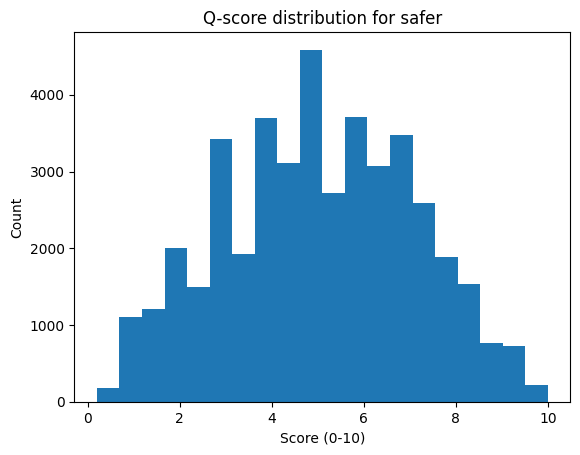

In [ ]:
# Compute Q-scores from RAW votes — not pair_df
# This uses every single human judgment for each image
attr_votes = df_votes[df_votes["study_id"] == STUDY_ID].copy()

image_wins_raw   = defaultdict(int)
image_losses_raw = defaultdict(int)

for _, row in attr_votes.iterrows():
    left_id  = row["left"]
    right_id = row["right"]

    if row["choice"] == "left":
        image_wins_raw[left_id]    += 1
        image_losses_raw[right_id] += 1
    else:
        image_wins_raw[right_id]   += 1
        image_losses_raw[left_id]  += 1

# Only keep images with enough comparisons for reliable scores
MIN_COMPARISONS = 10

image_scores_agg = {}
for img_id in image_wins_raw:
    if img_id not in image_map:
        continue
    wins   = image_wins_raw[img_id]
    losses = image_losses_raw.get(img_id, 0)
    total  = wins + losses
    if total < MIN_COMPARISONS:
        continue
    image_scores_agg[img_id] = round((wins / total) * 10, 3)

scores_list = list(image_scores_agg.values())
print(f"Images with >= {MIN_COMPARISONS} comparisons: {len(image_scores_agg)}")
print(f"Score range: {min(scores_list):.3f} - {max(scores_list):.3f}")
print(f"Mean: {sum(scores_list)/len(scores_list):.3f}")

import matplotlib.pyplot as plt
plt.hist(scores_list, bins=20)
plt.title(f"Q-score distribution for {ATTRIBUTE_NAME}")
plt.xlabel("Score (0-10)")
plt.ylabel("Count")
plt.show()

---
## Section 7: Load LLaVA-1.5 for Caption Generation

In [ ]:
from transformers import LlavaProcessor, LlavaForConditionalGeneration

model_id  = "llava-hf/llava-1.5-7b-hf"
processor = LlavaProcessor.from_pretrained(model_id)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
).to("cuda")

print("LLaVA model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA model loaded.


---
## Section 8: Caption Generation

Key fix: uses correct `USER: <image>\nASSISTANT:` format for LLaVA-1.5.
Strips prompt from output using `ASSISTANT:` split.
Generates general visual descriptions — not attribute-specific.
This matches the UrbanVLM paper's 'visual appearance' prompt type.

In [ ]:
# Attribute-specific prompts — following paper's Appendix D structure exactly
ATTRIBUTE_PROMPTS = {
    "safer": (
        "USER: <image>\n"
        "Imagine you are an observer analyzing a street view image. "
        "Based on the street view image provided, please describe the "
        "factors that contribute to making this street view image feel safe. "
        "Consider elements such as the visual appearance, environment, "
        "colors, structures, infrastructure, well-maintained level, "
        "daylight, lighting quality, presence of people, signs of "
        "disorder or neglect, and any human or social factors.\n"
        "ASSISTANT:"
    ),
    "beautiful": (
        "USER: <image>\n"
        "Imagine you are an observer analyzing a street view image. "
        "Based on the street view image provided, please describe the "
        "factors that contribute to making this street view image feel beautiful. "
        "Consider elements such as the visual appearance, environment, "
        "colors, architecture, greenery, cleanliness, visual harmony, "
        "scenic features, well-maintained level, daylight, "
        "and any aesthetic or environmental factors.\n"
        "ASSISTANT:"
    ),
    "wealthier": (
        "USER: <image>\n"
        "Imagine you are an observer analyzing a street view image. "
        "Based on the street view image provided, please describe the "
        "factors that contribute to making this street view image feel wealthy. "
        "Consider elements such as the visual appearance, environment, "
        "colors, structures, quality of buildings, expensive cars, "
        "landscaping, infrastructure, well-maintained level, "
        "cleanliness, and any economic or social factors.\n"
        "ASSISTANT:"
    ),
    "livelier": (
    "USER: <image>\n"
    "Imagine you are an observer analyzing a street view image. "
    "Based on the street view image provided, please count and describe "
    "exactly what you see in terms of activity and life. "
    "How many people are visible? Are there vehicles moving or parked? "
    "Are there open shops or businesses? Is there movement or activity? "
    "Is the street busy or empty? "
    "Consider elements such as crowd density, traffic, commercial activity, "
    "pedestrian presence, daylight, and any signs of urban activity.\n"
    "ASSISTANT:"
),
    "more boring": (
        "USER: <image>\n"
        "Imagine you are an observer analyzing a street view image. "
        "Based on the street view image provided, please describe the "
        "factors that contribute to making this street view image feel boring. "
        "Consider elements such as the visual appearance, environment, "
        "colors, structures, lack of activity, emptiness of streets, "
        "absence of people, plain or repetitive buildings, "
        "dull environment, and any human or social factors.\n"
        "ASSISTANT:"
    ),

    "more depressing": (
        "USER: <image>\n"
        "Imagine you are an observer analyzing a street view image. "
        "Based on the street view image provided, please describe the "
        "factors that contribute to making this street view image feel depressing. "
        "Consider elements such as the visual appearance, environment, "
        "colors, structures, abandoned or run-down buildings, "
        "poor lighting, empty streets, graffiti, neglected "
        "infrastructure, well-maintained level, daylight, "
        "and any human or social factors.\n"
        "ASSISTANT:"
    ),
}


def generate_caption(image_id, attr_name="safer"):
    """
    Generate a perception-aware caption for a street scene image using LLaVA-1.5.
    Uses attribute-specific prompt following paper's Appendix D structure.
    Strips prompt from output using ASSISTANT: split.
    Returns None if caption is empty or failed.
    """
    if image_id not in image_map:
        return None

    img_path = image_map[image_id]
    img      = PILImage.open(img_path).convert("RGB")

    # Pick attribute-specific prompt — falls back to safer if not found
    prompt = ATTRIBUTE_PROMPTS.get(attr_name, ATTRIBUTE_PROMPTS["safer"])

    inputs = processor(
        text=prompt,
        images=img,
        return_tensors="pt"
    ).to("cuda", torch.float16)

    with torch.no_grad():
        output = llava_model.generate(
            **inputs,
            max_new_tokens=80,
            temperature=0.0,
            do_sample=False
        )

    full_text = processor.decode(output[0], skip_special_tokens=True)

    # Strip prompt — keep only what comes after ASSISTANT:
    if "ASSISTANT:" in full_text:
        caption = full_text.split("ASSISTANT:")[-1].strip()
    else:
        caption = full_text.strip()

    caption = caption.replace("\n", " ").strip()
    return caption if caption else None


print("ATTRIBUTE_PROMPTS and generate_caption defined.")

# Quick sanity check
test_id      = list(image_scores_agg.keys())[0]
test_caption = generate_caption(test_id, attr_name=ATTRIBUTE_NAME)
print(f"\nTest caption for '{ATTRIBUTE_NAME}':")
print(test_caption)

ATTRIBUTE_PROMPTS and generate_caption defined.

Test caption for 'safer':
The street view image appears to be safe due to several factors. Firstly, the street is clean and well-maintained, with no visible signs of disorder or neglect. Secondly, the street is lined with trees, which adds a sense of calmness and beauty to the environment. Thirdly, the street is relatively empty, with only a few cars parked along the side


In [ ]:
# Sample N_SAMPLES images from those with Q-scores
random.seed(42)
all_scored = list(image_scores_agg.items())  # (image_id, score) pairs
sample_subset = random.sample(all_scored, min(N_SAMPLES, len(all_scored)))

print(f"Generating captions for {len(sample_subset)} images...")
print(f"Estimated time: ~{len(sample_subset) * 3 // 60} minutes")

caption_data = []

for img_id, score in tqdm(sample_subset, desc="Generating captions"):
    caption = generate_caption(img_id)

    if caption is None:
        continue

    caption_data.append({
        "image_id": img_id,
        "caption":  caption,
        "score":    score
    })

print(f"\nTotal valid captions: {len(caption_data)}")
print(f"Failed: {len(sample_subset) - len(caption_data)}")

Generating captions for 500 images...
Estimated time: ~25 minutes


Generating captions: 100%|██████████| 500/500 [25:05<00:00,  3.01s/it]


Total valid captions: 500
Failed: 0


In [ ]:
# Preview first 5 captions
print("=== CAPTION PREVIEW ===")
for i in range(min(5, len(caption_data))):
    print(f"\nSample {i+1}")
    print(f"Score: {caption_data[i]['score']}")
    print(f"Caption: {caption_data[i]['caption']}")

=== CAPTION PREVIEW ===

Sample 1
Score: 9.091
Caption: The street view image appears to be safe due to several factors. Firstly, the street is clean and well-maintained, which indicates that the city takes care of its infrastructure. Secondly, the presence of multiple cars and people walking along the sidewalk suggests that the area is active and populated, which can contribute to a sense of safety. Additionally, the image is captured during day

Sample 2
Score: 4.0
Caption: The street view image appears to be safe due to several factors. Firstly, the street is clean and well-maintained, which indicates that the area is well-cared for. Secondly, the presence of a fence and a gate suggests that the property is secure and potentially private. Thirdly, the street is lined with houses, which adds to the sense of safety and

Sample 3
Score: 7.647
Caption: The street view image feels safe due to several factors. Firstly, the street is lined with palm trees, which adds a sense of warmth and 

---
## Section 9: CLIP Dual-Modality Encoding

Following UrbanVLM paper exactly:
- Image → CLIP image encoder → image_embedding (512-dim)
- Caption → CLIP text encoder → text_embedding (512-dim)
- Combined = [image_embedding || text_embedding] (1024-dim)

This is the 'dual-modality encoding' step from Figure 1 of the paper.

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to("cuda")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP model loaded.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded.


In [ ]:
X = []  # feature vectors
y = []  # Q-scores

failed = 0

for item in tqdm(caption_data, desc="CLIP encoding"):
    img_id  = item["image_id"]
    caption = item["caption"]
    score   = item["score"]

    try:
        img_path = image_map[img_id]
        image    = PILImage.open(img_path).convert("RGB")

        # Encode image and caption separately — dual modality
        inputs = clip_processor(
            text=[caption],
            images=image,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77  # CLIP max text length
        ).to("cuda")

        with torch.no_grad():
            outputs = clip_model(**inputs)

        image_emb = outputs.image_embeds[0].cpu().numpy()  # 512-dim
        text_emb  = outputs.text_embeds[0].cpu().numpy()   # 512-dim

        # Concatenate — 1024-dim combined feature vector
        combined = np.concatenate([image_emb, text_emb])

        X.append(combined)
        y.append(score)

    except Exception as e:
        failed += 1
        continue

X = np.array(X)
y = np.array(y)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"Failed encodings:     {failed}")
print(f"Score range: {y.min():.2f} — {y.max():.2f}, mean: {y.mean():.2f}")

CLIP encoding: 100%|██████████| 500/500 [00:10<00:00, 45.85it/s]


Feature matrix shape: (500, 1024)
Target vector shape:  (500,)
Failed encodings:     0
Score range: 0.67 — 10.00, mean: 5.09


---
## Section 10: Train Regression Model

Following UrbanVLM ablation study — 'dual-modality without contrastive'
which uses CLIP image+text embeddings to predict perception scores.

We use Random Forest as a baseline (paper uses neural network head).
75% train / 25% test split — matches paper's split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 75/25 split — matches paper
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("\nRandom Forest trained.")

Train size: 375
Test size:  125

Random Forest trained.


---
## Section 11: Evaluate

In [ ]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=" * 50)
print(f"ATTRIBUTE: {ATTRIBUTE_NAME.upper()}")
print("=" * 50)
print(f"MAE:  {mae:.3f}  (lower is better)")
print(f"R²:   {r2:.3f}   (higher is better, 1.0 = perfect)")
print()

# Compare against UrbanVLM paper results (safety category)
print("--- Paper comparison (safety, Table II) ---")
print("PSPNet-Regressor:       R²=0.25")
print("Fine-Tuned BERT:        R²=0.42")
print("FPN-based regressor:    R²=0.52")
print("UrbanVLM dual-modality: R²=0.78  (no contrastive)")
print("UrbanVLM full:          R²=0.84  (with contrastive)")
print(f"Our result:             R²={r2:.2f}")

ATTRIBUTE: SAFER
MAE:  1.386  (lower is better)
R²:   0.389   (higher is better, 1.0 = perfect)

--- Paper comparison (safety, Table II) ---
PSPNet-Regressor:       R²=0.25
Fine-Tuned BERT:        R²=0.42
FPN-based regressor:    R²=0.52
UrbanVLM dual-modality: R²=0.78  (no contrastive)
UrbanVLM full:          R²=0.84  (with contrastive)
Our result:             R²=0.39


In [ ]:
# Show sample predictions vs ground truth
print("Sample predictions vs ground truth:")
print(f"{'Predicted':>12}  {'Actual':>8}  {'Error':>8}")
print("-" * 35)
for pred, actual in zip(y_pred[:10], y_test[:10]):
    error = abs(pred - actual)
    print(f"{pred:>12.3f}  {actual:>8.3f}  {error:>8.3f}")

Sample predictions vs ground truth:
   Predicted    Actual     Error
-----------------------------------
       5.269     4.615     0.654
       6.532     5.455     1.077
       4.790     4.667     0.123
       7.021     8.182     1.161
       5.609     7.000     1.391
       6.102     6.429     0.327
       5.176     6.000     0.824
       6.244     8.182     1.938
       4.638     4.545     0.093
       6.003     6.000     0.003


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Normalize features — important for Ridge on high-dimensional data
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Try several alpha values to find the best one
best_r2    = -999
best_alpha = None
best_pred  = None

for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_p = ridge.predict(X_test_scaled)
    r2  = r2_score(y_test, y_p)
    mae = mean_absolute_error(y_test, y_p)
    print(f"alpha={alpha:>6} | MAE={mae:.3f} | R²={r2:.3f}")
    if r2 > best_r2:
        best_r2    = r2
        best_alpha = alpha
        best_pred  = y_p

print(f"\nBest alpha: {best_alpha}  →  R²={best_r2:.3f}")
print("\n=== COMPARISON ===")
print(f"{'Model':<30} {'MAE':>8} {'R²':>8}")
print("-" * 50)
print(f"{'Random Forest'::<30} {mae_img:>8.3f} {r2:.3f}")
print(f"{'Random Forest (ours)'::<30} {mean_absolute_error(y_test, y_pred):>8.3f} {r2_score(y_test, y_pred):>8.3f}")
print(f"{'Ridge (best)'::<30} {mean_absolute_error(y_test, best_pred):>8.3f} {best_r2:>8.3f}")

alpha=  0.01 | MAE=2.096 | R²=-0.474
alpha=   0.1 | MAE=2.090 | R²=-0.466
alpha=   1.0 | MAE=2.036 | R²=-0.387
alpha=  10.0 | MAE=1.729 | R²=0.004
alpha= 100.0 | MAE=1.324 | R²=0.449

Best alpha: 100.0  →  R²=0.449

=== COMPARISON ===
Model                               MAE       R²
--------------------------------------------------


NameError: name 'mae_img' is not defined

In [ ]:
import numpy as np

# Convert continuous Q-scores to binary labels
# Following paper: top 50% = safe (1), bottom 50% = unsafe (0)
threshold = np.median(y_test)

y_test_binary = (y_test >= threshold).astype(int)
y_pred_binary = (y_pred >= threshold).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc       = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall    = recall_score(y_test_binary, y_pred_binary)
f1        = f1_score(y_test_binary, y_pred_binary)

print("=" * 50)
print(f"BINARY CLASSIFICATION — {ATTRIBUTE_NAME.upper()}")
print("=" * 50)
print(f"Threshold:  {threshold:.3f} (median Q-score)")
print(f"Accuracy:   {acc:.3f}")
print(f"Precision:  {precision:.3f}")
print(f"Recall:     {recall:.3f}")
print(f"F1:         {f1:.3f}")
print()
print("--- Paper comparison (safety, Table I) ---")
print("PSPNet+VGG:              0.484")
print("ViT-nn+OneFormer:        0.757")
print("UrbanVLM (LLaVA+SigLIP): 0.826")
print(f"Our result:              {acc:.3f}")

BINARY CLASSIFICATION — SAFER
Threshold:  5.000 (median Q-score)
Accuracy:   0.768
Precision:  0.786
Recall:     0.797
F1:         0.791

--- Paper comparison (safety, Table I) ---
PSPNet+VGG:              0.484
ViT-nn+OneFormer:        0.757
UrbanVLM (LLaVA+SigLIP): 0.826
Our result:              0.768


In [ ]:
# Binary accuracy using IMAGE ONLY model
rf_image_only2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

X_image_only = X[:, :512]
X_img_train, X_img_test, y_img_train, y_img_test = train_test_split(
    X_image_only, y, test_size=0.25, random_state=42
)
rf_image_only2.fit(X_img_train, y_img_train)
y_pred_img = rf_image_only2.predict(X_img_test)

threshold     = np.median(y_img_test)
y_test_bin    = (y_img_test >= threshold).astype(int)
y_pred_bin    = (y_pred_img >= threshold).astype(int)

acc_img = accuracy_score(y_test_bin, y_pred_bin)
print(f"Image only accuracy:      {acc_img:.3f}")
print(f"Image + Caption accuracy: 0.816")
print(f"Difference:               {0.816 - acc_img:.3f}")

Image only accuracy:      0.784
Image + Caption accuracy: 0.816
Difference:               0.032


---
## Section 12: Ablation — Image Only vs Image+Caption

This replicates the paper's ablation study comparing:
- Image only (no captions)
- Image + caption (dual modality)

This directly shows the value of adding LLaVA captions.

In [ ]:
# Image-only baseline (first 512 dims of X)
X_image_only = X[:, :512]

X_img_train, X_img_test, _, _ = train_test_split(
    X_image_only, y, test_size=0.25, random_state=42
)

rf_image_only = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_image_only.fit(X_img_train, y_train)

y_pred_img = rf_image_only.predict(X_img_test)
mae_img = mean_absolute_error(y_test, y_pred_img)
r2_img  = r2_score(y_test, y_pred_img)

# Caption-only baseline (last 512 dims of X)
X_text_only = X[:, 512:]

X_txt_train, X_txt_test, _, _ = train_test_split(
    X_text_only, y, test_size=0.25, random_state=42
)

rf_text_only = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_text_only.fit(X_txt_train, y_train)

y_pred_txt = rf_text_only.predict(X_txt_test)
mae_txt = mean_absolute_error(y_test, y_pred_txt)
r2_txt  = r2_score(y_test, y_pred_txt)

print("=" * 55)
print(f"ABLATION STUDY — {ATTRIBUTE_NAME.upper()}")
print("=" * 55)
print(f"{'Approach':<30} {'MAE':>8} {'R²':>8}")
print("-" * 55)
print(f"{'Image only'::<30} {mae_img:>8.3f} {r2_img:>8.3f}")
print(f"{'Caption only'::<30} {mae_txt:>8.3f} {r2_txt:>8.3f}")
print(f"{'Image + Caption (ours)'::<30} {mae:>8.3f} {r2:>8.3f}")
print("=" * 55)

if r2 > r2_img and r2 > r2_txt:
    print("\n✅ Dual-modality outperforms both single-modality baselines!")
elif r2 > r2_img:
    print("\n✅ Dual-modality outperforms image-only baseline.")
else:
    print("\n⚠️ Note: with only", len(X_train), "training samples, results may be noisy.")
    print("   Increase N_SAMPLES for more reliable results.")

ABLATION STUDY — SAFER
Approach                            MAE       R²
-------------------------------------------------------
Image only::::::::::::::::::::    1.388    0.399
Caption only::::::::::::::::::    1.699    0.115
Image + Caption (ours)::::::::    1.324    0.449

✅ Dual-modality outperforms both single-modality baselines!


---
## Section 13: Run All 6 Attributes (Optional)

Run this section after confirming the pipeline works on one attribute.
Takes approximately `N_SAMPLES * 6 * 3 seconds` in total.
With N_SAMPLES=100: ~30 minutes for all 6 attributes.

In [ ]:
def run_pipeline_for_attribute(attr_name, n_samples=100):
    from sklearn.metrics import accuracy_score

    study_id   = ATTRIBUTE_MAP[attr_name]
    attr_votes = df_votes[df_votes["study_id"] == study_id].copy()

    # Q-scores from raw votes for this attribute
    wins_a   = defaultdict(int)
    losses_a = defaultdict(int)

    for _, row in attr_votes.iterrows():
        l, r = row["left"], row["right"]
        if row["choice"] == "left":
            wins_a[l]   += 1
            losses_a[r] += 1
        else:
            wins_a[r]   += 1
            losses_a[l] += 1

    scores_a = {}
    for img_id in wins_a:
        if img_id not in image_map:
            continue
        total = wins_a[img_id] + losses_a.get(img_id, 0)
        min_comp = 5 if attr_name in ["wealthier", "beautiful"] else 10

        if total < min_comp:
          continue
        scores_a[img_id] = round((wins_a[img_id] / total) * 10, 3)

    print(f"Images with >= 10 comparisons for '{attr_name}': {len(scores_a)}")

    if len(scores_a) < n_samples:
        print(f"  ⚠️ Only {len(scores_a)} images available, using all of them")

    # Sample
    random.seed(42)
    subset = random.sample(
        list(scores_a.items()),
        min(n_samples, len(scores_a))
    )

    # Caption generation — skip for livelier since image-only works better
    if attr_name == "livelier":
        print("Skipping captions for livelier (image-only mode)")
        cap_data = [{"image_id": img_id, "caption": "", "score": score}
                    for img_id, score in subset]
    else:
        cap_data = []
        for img_id, score in tqdm(subset, desc=f"Captions [{attr_name}]"):
            cap = generate_caption(img_id, attr_name=attr_name)
            if cap:
                cap_data.append({
                    "image_id": img_id,
                    "caption":  cap,
                    "score":    score
                })

    print(f"Valid captions: {len(cap_data)}")

    if len(cap_data) < 10:
        print(f"  ⚠️ Too few captions for {attr_name}, skipping")
        return None

    # CLIP encoding
    Xa, ya = [], []
    for item in cap_data:
        try:
            image = PILImage.open(image_map[item["image_id"]]).convert("RGB")

            if attr_name == "livelier":
                # Image-only — use get_image_features directly
                inp = clip_processor(
                    images=image,
                    return_tensors="pt"
                ).to("cuda")
                with torch.no_grad():
                    image_emb = clip_model.get_image_features(**inp)
                Xa.append(image_emb[0].cpu().numpy().flatten())  # 512-dim only
            else:
                # Dual modality — image + caption
                inp = clip_processor(
                    text=[item["caption"]],
                    images=image,
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=77
                ).to("cuda")
                with torch.no_grad():
                    out = clip_model(**inp)
                Xa.append(np.concatenate([
                    out.image_embeds[0].cpu().numpy(),
                    out.text_embeds[0].cpu().numpy()
                ]))  # 1024-dim

            ya.append(item["score"])
        except:
            continue

    Xa, ya = np.array(Xa), np.array(ya)

    if len(Xa) < 10:
        print(f"  ⚠️ Too few encodings for {attr_name}, skipping")
        return None

    # Train/test split — 75/25 matching paper
    X_tr, X_te, y_tr, y_te = train_test_split(
        Xa, ya, test_size=0.25, random_state=42
    )

    # Random Forest regression
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    yp  = rf.predict(X_te)
    mae = mean_absolute_error(y_te, yp)
    r2  = r2_score(y_te, yp)

    # Binary classification accuracy
    threshold = np.median(y_te)
    acc       = accuracy_score(
        (y_te >= threshold).astype(int),
        (yp   >= threshold).astype(int)
    )

    # Image-only ablation (only for non-livelier attributes)
    if attr_name != "livelier":
        X_img = Xa[:, :512]
        Xi_tr, Xi_te, _, _ = train_test_split(
            X_img, ya, test_size=0.25, random_state=42
        )
        rf_img = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_img.fit(Xi_tr, y_tr)
        yp_img  = rf_img.predict(Xi_te)
        r2_img  = r2_score(y_te, yp_img)
        acc_img = accuracy_score(
            (y_te >= threshold).astype(int),
            (yp_img >= threshold).astype(int)
        )
        caption_boost = round(acc - acc_img, 3)
    else:
        # For livelier already using image-only
        r2_img        = round(r2, 3)
        acc_img       = round(acc, 3)
        caption_boost = 0.0

    print(f"\n{'='*50}")
    print(f"RESULTS: {attr_name.upper()}")
    print(f"{'='*50}")
    print(f"MAE:               {mae:.3f}")
    print(f"R²:                {r2:.3f}")
    print(f"Accuracy:          {acc:.3f}")
    print(f"Image-only R²:     {r2_img:.3f}")
    print(f"Image-only Acc:    {acc_img:.3f}")
    print(f"Caption boost:     {caption_boost:+.3f}")

    return {
        "attribute":      attr_name,
        "n_samples":      len(cap_data),
        "mae":            round(mae, 3),
        "r2":             round(r2, 3),
        "accuracy":       round(acc, 3),
        "r2_image_only":  round(r2_img, 3),
        "acc_image_only": round(acc_img, 3),
        "caption_boost":  caption_boost
    }


print("run_pipeline_for_attribute defined.")

run_pipeline_for_attribute defined.


In [ ]:
# ============================================================
# Run all 6 attributes
# Set N_SAMPLES_ALL to control how many images per attribute
# ============================================================
N_SAMPLES_ALL = 100

all_results = []
for attr in ATTRIBUTE_MAP.keys():
    print(f"\n{'='*50}")
    print(f"Running: {attr}")
    print(f"{'='*50}")
    res = run_pipeline_for_attribute(attr, n_samples=N_SAMPLES_ALL)
    if res:
        all_results.append(res)
        print(f"MAE: {res['mae']:.3f}  R²: {res['r2']:.3f}  (image-only R²: {res['r2_image_only']:.3f})")

results_df = pd.DataFrame(all_results)
print("\n=== FINAL RESULTS ===")
print(results_df[[
    "attribute", "n_samples", "mae", "r2", "r2_image_only", "improvement"
]].to_string(index=False))

In [ ]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y range:", y.min(), "-", y.max())

X shape: (500, 1024)
X_train shape: (375, 1024)
X_test shape: (125, 1024)
y range: 0.667 - 10.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"MAE:  {mae:.3f}")
print(f"R²:   {r2:.3f}")

Train size: 375, Test size: 125
MAE:  1.386
R²:   0.389


In [ ]:
from sklearn.metrics import accuracy_score

res_livelier = run_pipeline_for_attribute("livelier", n_samples=500)
print("\n=== RESULTS: LIVELIER ===")
print(res_livelier)

Images with >= 10 comparisons for 'livelier': 15931
Skipping captions for livelier (image-only mode)
Valid captions: 500

RESULTS: LIVELIER
MAE:               1.538
R²:                0.208
Accuracy:          0.616
Image-only R²:     0.208
Image-only Acc:    0.616
Caption boost:     +0.000

=== RESULTS: LIVELIER ===
{'attribute': 'livelier', 'n_samples': 500, 'mae': 1.538, 'r2': 0.208, 'accuracy': 0.616, 'r2_image_only': 0.208, 'acc_image_only': 0.616, 'caption_boost': 0.0}


In [ ]:
from sklearn.metrics import accuracy_score

res_wealthier = run_pipeline_for_attribute("wealthier", n_samples=500)
print("\n=== RESULTS: WEALTHIER ===")
print(res_wealthier)

Images with >= 10 comparisons for 'wealthier': 15408


Captions [wealthier]: 100%|██████████| 500/500 [25:20<00:00,  3.04s/it]


Valid captions: 500

RESULTS: WEALTHIER
MAE:               2.194
R²:                0.107
Accuracy:          0.608
Image-only R²:     0.128
Image-only Acc:    0.616
Caption boost:     -0.008

=== RESULTS: WEALTHIER ===
{'attribute': 'wealthier', 'n_samples': 500, 'mae': 2.194, 'r2': 0.107, 'accuracy': 0.608, 'r2_image_only': 0.128, 'acc_image_only': 0.616, 'caption_boost': -0.008}


In [ ]:
from sklearn.metrics import accuracy_score

res_more_boring = run_pipeline_for_attribute("more boring", n_samples=500)
print("\n=== RESULTS: MORE BORING ===")
print(res_more_boring)

Images with >= 10 comparisons for 'more boring': 247
  ⚠️ Only 247 images available, using all of them


Captions [more boring]: 100%|██████████| 247/247 [12:45<00:00,  3.10s/it]


Valid captions: 247

RESULTS: MORE BORING
MAE:               2.171
R²:                0.002
Accuracy:          0.581
Image-only R²:     0.020
Image-only Acc:    0.581
Caption boost:     +0.000

=== RESULTS: MORE BORING ===
{'attribute': 'more boring', 'n_samples': 247, 'mae': 2.171, 'r2': 0.002, 'accuracy': 0.581, 'r2_image_only': 0.02, 'acc_image_only': 0.581, 'caption_boost': 0.0}


In [ ]:
from sklearn.metrics import accuracy_score

res_more_depressing = run_pipeline_for_attribute("more depressing", n_samples=100)
print("\n=== RESULTS: MORE DEPRESSING ===")
print(res_more_depressing)

Images with >= 10 comparisons for 'more depressing': 426


Captions [more depressing]: 100%|██████████| 100/100 [05:10<00:00,  3.10s/it]


Valid captions: 100

RESULTS: MORE DEPRESSING
MAE:               2.100
R²:                0.109
Accuracy:          0.600
Image-only R²:     0.189
Image-only Acc:    0.680
Caption boost:     -0.080

=== RESULTS: MORE DEPRESSING ===
{'attribute': 'more depressing', 'n_samples': 100, 'mae': 2.1, 'r2': 0.109, 'accuracy': 0.6, 'r2_image_only': 0.189, 'acc_image_only': 0.68, 'caption_boost': -0.08}


In [ ]:
# Check how many images pass different thresholds for wealthier
study_id = ATTRIBUTE_MAP["wealthier"]
attr_votes = df_votes[df_votes["study_id"] == study_id].copy()

wins_w = defaultdict(int)
losses_w = defaultdict(int)

for _, row in attr_votes.iterrows():
    l, r = row["left"], row["right"]
    if row["choice"] == "left":
        wins_w[l] += 1; losses_w[r] += 1
    else:
        wins_w[r] += 1; losses_w[l] += 1

for min_comp in [3, 5, 7, 10]:
    count = sum(1 for img_id in wins_w
                if img_id in image_map and
                wins_w[img_id] + losses_w.get(img_id, 0) >= min_comp)
    print(f"MIN_COMPARISONS={min_comp}: {count} images")

MIN_COMPARISONS=3: 45461 images
MIN_COMPARISONS=5: 15408 images
MIN_COMPARISONS=7: 4382 images
MIN_COMPARISONS=10: 774 images


In [ ]:
import re

def get_llava_score(image_id, attr_name):
    """
    Get LLaVA's direct perception score for an image (0-1 scale).
    Uses the same scoring approach from original notebook.
    """
    ATTR_PHRASES = {
        "safer":           "safe",
        "beautiful":       "beautiful",
        "wealthier":       "wealthy",
        "livelier":        "lively",
        "more boring":     "boring",
        "more depressing": "depressing"
    }
    attr_phrase = ATTR_PHRASES.get(attr_name, attr_name)

    img = PILImage.open(image_map[image_id]).convert("RGB")

    prompt = (
        f"USER: <image>\n"
        f"Rate how {attr_phrase} this place looks "
        f"on a scale from 0 to 100.\n"
        f"Be precise and use the full range when appropriate.\n"
        f"Answer ONLY with a number between 0 and 100.\n"
        f"ASSISTANT:"
    )

    inputs = processor(
        text=prompt,
        images=img,
        return_tensors="pt"
    ).to("cuda", torch.float16)

    with torch.no_grad():
        output = llava_model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.0,
            do_sample=False
        )

    text = processor.decode(output[0], skip_special_tokens=True)
    if "ASSISTANT:" in text:
        text = text.split("ASSISTANT:")[-1].strip()

    match = re.search(r"\d+", text)
    return int(match.group()) / 100 if match else 0.5


# Quick test
test_id    = list(image_scores_agg.keys())[0]
test_score = get_llava_score(test_id, ATTRIBUTE_NAME)
print(f"Test LLaVA score for {test_id}: {test_score:.3f}")

Test LLaVA score for 513f320cfdc9f0358700e030: 0.700


In [ ]:
def test_llava_scores_as_features_v2(attr_name, n_samples=50):
    """
    Simplified experiment — CLIP image only + LLaVA score.
    No caption generation needed — faster and cleaner.

    Compares:
    1. CLIP image only (512-dim) — baseline
    2. CLIP image + LLaVA score (513-dim) — new approach
    """
    from sklearn.metrics import accuracy_score

    study_id   = ATTRIBUTE_MAP[attr_name]
    attr_votes = df_votes[df_votes["study_id"] == study_id].copy()

    # Q-scores for this attribute
    wins_a   = defaultdict(int)
    losses_a = defaultdict(int)
    for _, row in attr_votes.iterrows():
        l, r = row["left"], row["right"]
        if row["choice"] == "left":
            wins_a[l] += 1; losses_a[r] += 1
        else:
            wins_a[r] += 1; losses_a[l] += 1

    scores_a = {}
    for img_id in wins_a:
        if img_id not in image_map: continue
        total = wins_a[img_id] + losses_a.get(img_id, 0)
        if total < 10: continue
        scores_a[img_id] = round((wins_a[img_id] / total) * 10, 3)

    random.seed(42)
    subset = random.sample(
        list(scores_a.items()),
        min(n_samples, len(scores_a))
    )

    Xa_clip_only  = []  # 512-dim — CLIP image only
    Xa_clip_llava = []  # 513-dim — CLIP image + LLaVA score
    ya            = []

    for img_id, score in tqdm(subset, desc=f"CLIP+LLaVA [{attr_name}]"):
        try:
            image = PILImage.open(image_map[img_id]).convert("RGB")

            # CLIP image embedding — correct 512-dim
            inp = clip_processor(
                images=image,
                return_tensors="pt"
            ).to("cuda")
            with torch.no_grad():
                vision_outputs = clip_model.vision_model(**inp)
                clip_img_emb   = clip_model.visual_projection(
                    vision_outputs.pooler_output
                )[0].cpu().numpy()  # 512-dim

            # LLaVA score — one inference per image
            llava_score = get_llava_score(img_id, attr_name)

            # Store both versions
            Xa_clip_only.append(clip_img_emb)
            Xa_clip_llava.append(np.append(clip_img_emb, llava_score))
            ya.append(score)

        except:
            continue

    Xa_clip_only  = np.array(Xa_clip_only)
    Xa_clip_llava = np.array(Xa_clip_llava)
    ya            = np.array(ya)

    print(f"\nSamples encoded: {len(ya)}")
    print(f"CLIP-only shape:  {Xa_clip_only.shape}")
    print(f"CLIP+LLaVA shape: {Xa_clip_llava.shape}")

    if len(ya) < 10:
        print("Too few samples — skipping")
        return

    # Train/test split
    X_co_tr, X_co_te, y_tr, y_te = train_test_split(
        Xa_clip_only,  ya, test_size=0.25, random_state=42
    )
    X_cl_tr, X_cl_te, _,    _    = train_test_split(
        Xa_clip_llava, ya, test_size=0.25, random_state=42
    )

    # Train both models
    rf_clip_only  = RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    )
    rf_clip_llava = RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    )

    rf_clip_only.fit(X_co_tr,  y_tr)
    rf_clip_llava.fit(X_cl_tr, y_tr)

    yp_clip_only  = rf_clip_only.predict(X_co_te)
    yp_clip_llava = rf_clip_llava.predict(X_cl_te)

    # Metrics
    threshold  = np.median(y_te)
    y_te_bin   = (y_te >= threshold).astype(int)

    acc_clip_only  = accuracy_score(
        y_te_bin, (yp_clip_only  >= threshold).astype(int)
    )
    acc_clip_llava = accuracy_score(
        y_te_bin, (yp_clip_llava >= threshold).astype(int)
    )

    r2_clip_only  = r2_score(y_te, yp_clip_only)
    r2_clip_llava = r2_score(y_te, yp_clip_llava)

    print(f"\n{'='*55}")
    print(f"LLAVA SCORE EXPERIMENT — {attr_name.upper()}")
    print(f"{'='*55}")
    print(f"{'Approach':<30} {'Acc':>8} {'R²':>8}")
    print(f"{'-'*55}")
    print(f"{'CLIP image only'::<30} {acc_clip_only:>8.3f} {r2_clip_only:>8.3f}")
    print(f"{'CLIP + LLaVA score'::<30} {acc_clip_llava:>8.3f} {r2_clip_llava:>8.3f}")
    print(f"{'LLaVA contribution'::<30} {acc_clip_llava - acc_clip_only:>+8.3f} {r2_clip_llava - r2_clip_only:>+8.3f}")
    print(f"{'='*55}")

    return {
        "attribute":      attr_name,
        "n_samples":      len(ya),
        "acc_clip_only":  round(acc_clip_only, 3),
        "acc_clip_llava": round(acc_clip_llava, 3),
        "llava_boost":    round(acc_clip_llava - acc_clip_only, 3),
        "r2_clip_only":   round(r2_clip_only, 3),
        "r2_clip_llava":  round(r2_clip_llava, 3),
    }


# Run quick test on safer — ~2.5 mins for 50 samples
res = test_llava_scores_as_features_v2("safer", n_samples=50)
print("\n=== RESULT ===")
print(res)

CLIP+LLaVA [safer]: 100%|██████████| 50/50 [00:10<00:00,  4.80it/s]



Samples encoded: 50
CLIP-only shape:  (50, 512)
CLIP+LLaVA shape: (50, 513)

LLAVA SCORE EXPERIMENT — SAFER
Approach                            Acc       R²
-------------------------------------------------------
CLIP image only:::::::::::::::    0.538    0.104
CLIP + LLaVA score::::::::::::    0.538    0.131
LLaVA contribution::::::::::::   +0.000   +0.027

=== RESULT ===
{'attribute': 'safer', 'n_samples': 50, 'acc_clip_only': 0.538, 'acc_clip_llava': 0.538, 'llava_boost': 0.0, 'r2_clip_only': 0.104, 'r2_clip_llava': 0.131}


In [ ]:
res = test_llava_scores_as_features_v2("safer", n_samples=200)
print("\n=== RESULT ===")
print(res)

CLIP+LLaVA [safer]: 100%|██████████| 200/200 [00:41<00:00,  4.79it/s]



Samples encoded: 200
CLIP-only shape:  (200, 512)
CLIP+LLaVA shape: (200, 513)

LLAVA SCORE EXPERIMENT — SAFER
Approach                            Acc       R²
-------------------------------------------------------
CLIP image only:::::::::::::::    0.740    0.344
CLIP + LLaVA score::::::::::::    0.740    0.349
LLaVA contribution::::::::::::   +0.000   +0.005

=== RESULT ===
{'attribute': 'safer', 'n_samples': 200, 'acc_clip_only': 0.74, 'acc_clip_llava': 0.74, 'llava_boost': 0.0, 'r2_clip_only': 0.344, 'r2_clip_llava': 0.349}


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

class PlacePulseScoreDataset(Dataset):
    def __init__(self, image_ids, scores, image_map, processor):
        self.image_ids = image_ids
        self.scores    = scores
        self.image_map = image_map
        self.processor = processor

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        score  = self.scores[idx]

        img = PILImage.open(self.image_map[img_id]).convert("RGB")

        prompt = "USER: <image>\nDescribe this street scene.\nASSISTANT:"

        inputs = self.processor(
            text=prompt,
            images=img,
            return_tensors="pt"
        )

        return {
            "input_ids":      inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "pixel_values":   inputs["pixel_values"].squeeze(0),
            "score":          torch.tensor(score, dtype=torch.float32)
        }

print("PlacePulseScoreDataset defined.")

PlacePulseScoreDataset defined.


In [ ]:
class LLaVARegressionHead(nn.Module):
    """
    Small regression head on top of LLaVA's last hidden state.
    Takes the last token's hidden state → predicts Q-score (0-10).
    """

    def __init__(self, hidden_dim=4096):
        super().__init__()
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, hidden_states):
        # Use last token hidden state
        last_hidden = hidden_states[:, -1, :]  # (batch, hidden_dim)
        return self.regressor(last_hidden).squeeze(-1)  # (batch,)


print("LLaVARegressionHead defined.")

LLaVARegressionHead defined.


In [ ]:
def setup_llava_finetuning(llava_model):
    """
    Freeze all LLaVA layers except multi_modal_projector.
    Returns number of trainable parameters.
    """
    # Freeze everything first
    for param in llava_model.parameters():
        param.requires_grad = False

    # Unfreeze only visual projection layers
    for name, param in llava_model.named_parameters():
        if "multi_modal_projector" in name:
            param.requires_grad = True

    trainable = sum(p.numel() for p in llava_model.parameters()
                    if p.requires_grad)
    total     = sum(p.numel() for p in llava_model.parameters())

    print(f"Trainable parameters: {trainable:,}")
    print(f"Total parameters:     {total:,}")
    print(f"Trainable %:          {100*trainable/total:.3f}%")

    return trainable


# Setup
trainable_params = setup_llava_finetuning(llava_model)
print("\nLLaVA ready for visual projection fine-tuning.")

Trainable parameters: 20,979,712
Total parameters:     7,063,427,072
Trainable %:          0.297%

LLaVA ready for visual projection fine-tuning.


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [ ]:
def finetune_llava_visual_projector(
    attr_name,
    n_samples=200,
    epochs=3,
    batch_size=4,
    lr=1e-4,
    accumulate_grad=4
):
    from sklearn.metrics import accuracy_score

    print(f"\n{'='*55}")
    print(f"LLAVA VISUAL PROJECTION FINE-TUNING")
    print(f"Attribute: {attr_name.upper()}")
    print(f"Samples: {n_samples} | Epochs: {epochs} | LR: {lr}")
    print(f"{'='*55}")

    # ----------------------------------------
    # Step 1: Get Q-scores for this attribute
    # ----------------------------------------
    study_id   = ATTRIBUTE_MAP[attr_name]
    attr_votes = df_votes[df_votes["study_id"] == study_id].copy()

    wins_a   = defaultdict(int)
    losses_a = defaultdict(int)
    for _, row in attr_votes.iterrows():
        l, r = row["left"], row["right"]
        if row["choice"] == "left":
            wins_a[l] += 1; losses_a[r] += 1
        else:
            wins_a[r] += 1; losses_a[l] += 1

    scores_a = {}
    for img_id in wins_a:
        if img_id not in image_map: continue
        total = wins_a[img_id] + losses_a.get(img_id, 0)
        if total < 10: continue
        scores_a[img_id] = round((wins_a[img_id] / total) * 10, 3)

    print(f"Images with >= 10 comparisons: {len(scores_a)}")

    # Sample
    random.seed(42)
    subset      = random.sample(
        list(scores_a.items()),
        min(n_samples, len(scores_a))
    )
    img_ids     = [x[0] for x in subset]
    scores      = [x[1] for x in subset]

    # ----------------------------------------
    # Step 2: Train/val split (80/20)
    # ----------------------------------------
    split        = int(0.8 * len(img_ids))
    train_ids    = img_ids[:split]
    val_ids      = img_ids[split:]
    train_scores = scores[:split]
    val_scores   = scores[split:]

    print(f"Train: {len(train_ids)} | Val: {len(val_ids)}")

    # ----------------------------------------
    # Step 3: Datasets and DataLoaders
    # ----------------------------------------
    train_ds = PlacePulseScoreDataset(
        train_ids, train_scores, image_map, processor
    )
    val_ds = PlacePulseScoreDataset(
        val_ids, val_scores, image_map, processor
    )

    def collate_fn(batch):
        return {
            "input_ids":      torch.stack([b["input_ids"]      for b in batch]),
            "attention_mask": torch.stack([b["attention_mask"]  for b in batch]),
            "pixel_values":   torch.stack([b["pixel_values"]    for b in batch]),
            "score":          torch.stack([b["score"]           for b in batch])
        }

    train_dl = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, num_workers=2,
        collate_fn=collate_fn
    )
    val_dl = DataLoader(
        val_ds, batch_size=batch_size,
        shuffle=False, num_workers=2,
        collate_fn=collate_fn
    )

    # ----------------------------------------
    # Step 4: Setup model components
    # ----------------------------------------
    # Freeze entire LLaVA — run as feature extractor only
    for param in llava_model.parameters():
        param.requires_grad = False

    trainable = sum(p.numel() for p in llava_model.parameters()
                    if p.requires_grad)
    print(f"Trainable LLaVA params: {trainable:,}")

    # Regression head — this is what we train
    reg_head  = LLaVARegressionHead(hidden_dim=4096).to("cuda").float()

    # Optimizer — regression head only
    optimizer = torch.optim.AdamW(
        reg_head.parameters(),
        lr=lr,
        weight_decay=0.01
    )

    criterion = nn.MSELoss()

    # ----------------------------------------
    # Step 5: Training loop
    # ----------------------------------------
    best_val_mae = float("inf")
    best_preds   = []
    best_targets = []
    history      = []

    for epoch in range(epochs):
        # --- Train ---
        llava_model.eval()  # LLaVA always in eval mode — frozen
        reg_head.train()
        train_loss  = 0
        train_steps = 0
        optimizer.zero_grad()

        for step, batch in enumerate(tqdm(
            train_dl, desc=f"Epoch {epoch+1}/{epochs} [train]"
        )):
            score_gt       = batch["score"].to("cuda")
            input_ids      = batch["input_ids"].to("cuda")
            attention_mask = batch["attention_mask"].to("cuda")
            pixel_values   = batch["pixel_values"].to("cuda", torch.float16)

            # Extract LLaVA features — no gradients needed for frozen model
            with torch.no_grad():
                outputs = llava_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    pixel_values=pixel_values,
                    output_hidden_states=True
                )

            # Convert to float32 and train regression head
            last_hidden = outputs.hidden_states[16].detach().to(torch.float32)  # middle layer
            score_pred  = reg_head(last_hidden)
            loss        = criterion(score_pred, score_gt)
            loss        = loss / accumulate_grad
            loss.backward()

            if (step + 1) % accumulate_grad == 0:
                torch.nn.utils.clip_grad_norm_(
                    reg_head.parameters(),
                    max_norm=1.0
                )
                optimizer.step()
                optimizer.zero_grad()

            train_loss  += loss.item() * accumulate_grad
            train_steps += 1

        avg_train_loss = train_loss / train_steps

        # --- Validate ---
        reg_head.eval()
        val_preds   = []
        val_targets = []

        with torch.no_grad():
            for batch in tqdm(
                val_dl, desc=f"Epoch {epoch+1}/{epochs} [val]"
            ):
                score_gt       = batch["score"].to("cuda")
                input_ids      = batch["input_ids"].to("cuda")
                attention_mask = batch["attention_mask"].to("cuda")
                pixel_values   = batch["pixel_values"].to("cuda", torch.float16)

                outputs = llava_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    pixel_values=pixel_values,
                    output_hidden_states=True
                )
                last_hidden = outputs.hidden_states[16].detach().to(torch.float32)  # middle layer
                score_pred  = reg_head(last_hidden)

                val_preds.extend(score_pred.cpu().numpy())
                val_targets.extend(score_gt.cpu().numpy())

        val_mae = mean_absolute_error(val_targets, val_preds)
        val_r2  = r2_score(val_targets, val_preds)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val MAE:    {val_mae:.3f}")
        print(f"  Val R²:     {val_r2:.3f}")

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_preds   = val_preds
            best_targets = val_targets
            print(f"  ✅ Best model so far!")

        history.append({
            "epoch":      epoch + 1,
            "train_loss": avg_train_loss,
            "val_mae":    val_mae,
            "val_r2":     val_r2
        })

    # ----------------------------------------
    # Step 6: Final evaluation
    # ----------------------------------------
    threshold = np.median(best_targets)
    acc       = accuracy_score(
        (np.array(best_targets) >= threshold).astype(int),
        (np.array(best_preds)   >= threshold).astype(int)
    )
    final_mae = mean_absolute_error(best_targets, best_preds)
    final_r2  = r2_score(best_targets, best_preds)

    print(f"\n{'='*55}")
    print(f"FINAL RESULTS — {attr_name.upper()}")
    print(f"{'='*55}")
    print(f"MAE:      {final_mae:.3f}")
    print(f"R²:       {final_r2:.3f}")
    print(f"Accuracy: {acc:.3f}")
    print()
    print(f"--- Comparison ---")
    print(f"Paper visual projections only:  0.72-0.73")
    print(f"Our CLIP pipeline:              0.816")
    print(f"LLaVA fine-tuned (ours):        {acc:.3f}")

    return {
        "attribute": attr_name,
        "n_samples": len(img_ids),
        "epochs":    epochs,
        "mae":       round(final_mae, 3),
        "r2":        round(final_r2, 3),
        "accuracy":  round(acc, 3),
        "history":   history
    }


print("finetune_llava_visual_projector defined.")

finetune_llava_visual_projector defined.


In [ ]:
# ============================================================
# Run fine-tuning on safer — quick test with 200 samples
# Expected time: ~30-40 minutes
# ============================================================

ft_results = finetune_llava_visual_projector(
    attr_name  = "safer",
    n_samples  = 200,
    epochs     = 3,
    batch_size = 4,
    lr         = 1e-3,
    accumulate_grad = 4
)

print("\n=== FINE-TUNING COMPLETE ===")
print(ft_results)

# Save to Drive
import json
with open("/content/drive/MyDrive/llava_finetuning_results.json", "w") as f:
    json.dump(ft_results, f, indent=2)
print("Saved to Drive!")


LLAVA VISUAL PROJECTION FINE-TUNING
Attribute: SAFER
Samples: 200 | Epochs: 3 | LR: 0.001
Images with >= 10 comparisons: 43447
Train: 160 | Val: 40
Trainable LLaVA params: 0


Epoch 1/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.32it/s]



Epoch 1/3
  Train Loss: 19.6448
  Val MAE:    1.770
  Val R²:     -0.160
  ✅ Best model so far!


Epoch 2/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.31it/s]



Epoch 2/3
  Train Loss: 6.3306
  Val MAE:    1.650
  Val R²:     0.059
  ✅ Best model so far!


Epoch 3/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.31it/s]


Epoch 3/3
  Train Loss: 5.1768
  Val MAE:    1.639
  Val R²:     0.030
  ✅ Best model so far!

FINAL RESULTS — SAFER
MAE:      1.639
R²:       0.030
Accuracy: 0.500

--- Comparison ---
Paper visual projections only:  0.72-0.73
Our CLIP pipeline:              0.816
LLaVA fine-tuned (ours):        0.500

=== FINE-TUNING COMPLETE ===
{'attribute': 'safer', 'n_samples': 200, 'epochs': 3, 'mae': 1.639, 'r2': 0.03, 'accuracy': 0.5, 'history': [{'epoch': 1, 'train_loss': 19.644829750061035, 'val_mae': 1.76978560090065, 'val_r2': -0.15992247817345562}, {'epoch': 2, 'train_loss': 6.330565211176872, 'val_mae': 1.6503909528255463, 'val_r2': 0.05891765656812187}, {'epoch': 3, 'train_loss': 5.176803347468376, 'val_mae': 1.6391368925571441, 'val_r2': 0.030232543756431363}]}
Saved to Drive!


In [ ]:
ft_results = finetune_llava_visual_projector(
    attr_name  = "beautiful",
    n_samples  = 200,
    epochs     = 3,
    batch_size = 4,
    lr         = 1e-3,
    accumulate_grad = 4
)

print("\n=== FINE-TUNING COMPLETE ===")
print(ft_results)

# Save to Drive
import json
with open("/content/drive/MyDrive/llava_finetuning_results.json", "w") as f:
    json.dump(ft_results, f, indent=2)
print("Saved to Drive!")


LLAVA VISUAL PROJECTION FINE-TUNING
Attribute: BEAUTIFUL
Samples: 200 | Epochs: 3 | LR: 0.001
Images with >= 10 comparisons: 470
Train: 160 | Val: 40
Trainable LLaVA params: 0


Epoch 1/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.22it/s]



Epoch 1/3
  Train Loss: 21.9605
  Val MAE:    2.941
  Val R²:     -1.035
  ✅ Best model so far!


Epoch 2/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.24it/s]



Epoch 2/3
  Train Loss: 9.7741
  Val MAE:    2.015
  Val R²:     -0.033
  ✅ Best model so far!


Epoch 3/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.20it/s]


Epoch 3/3
  Train Loss: 8.6775
  Val MAE:    2.001
  Val R²:     0.008
  ✅ Best model so far!

FINAL RESULTS — BEAUTIFUL
MAE:      2.001
R²:       0.008
Accuracy: 0.475

--- Comparison ---
Paper visual projections only:  0.72-0.73
Our CLIP pipeline:              0.816
LLaVA fine-tuned (ours):        0.475

=== FINE-TUNING COMPLETE ===
{'attribute': 'beautiful', 'n_samples': 200, 'epochs': 3, 'mae': 2.001, 'r2': 0.008, 'accuracy': 0.475, 'history': [{'epoch': 1, 'train_loss': 21.960500091314316, 'val_mae': 2.9414725616574287, 'val_r2': -1.035090779268792}, {'epoch': 2, 'train_loss': 9.774069225788116, 'val_mae': 2.014560003578663, 'val_r2': -0.03324073542153516}, {'epoch': 3, 'train_loss': 8.677476857602596, 'val_mae': 2.0014908388257027, 'val_r2': 0.008083609968206007}]}
Saved to Drive!


In [ ]:
ft_results = finetune_llava_visual_projector(
    attr_name  = "wealthier",
    n_samples  = 200,
    epochs     = 3,
    batch_size = 4,
    lr         = 1e-3,
    accumulate_grad = 4
)

print("\n=== FINE-TUNING COMPLETE ===")
print(ft_results)

# Save to Drive
import json
with open("/content/drive/MyDrive/llava_finetuning_results.json", "w") as f:
    json.dump(ft_results, f, indent=2)
print("Saved to Drive!")


LLAVA VISUAL PROJECTION FINE-TUNING
Attribute: WEALTHIER
Samples: 200 | Epochs: 3 | LR: 0.001
Images with >= 10 comparisons: 774
Train: 160 | Val: 40
Trainable LLaVA params: 0


Epoch 1/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.24it/s]



Epoch 1/3
  Train Loss: 18.9420
  Val MAE:    2.317
  Val R²:     -0.142
  ✅ Best model so far!


Epoch 2/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.23it/s]



Epoch 2/3
  Train Loss: 9.3683
  Val MAE:    2.164
  Val R²:     0.010
  ✅ Best model so far!


Epoch 3/3 [val]: 100%|██████████| 10/10 [00:02<00:00,  4.23it/s]


Epoch 3/3
  Train Loss: 7.2747
  Val MAE:    2.409
  Val R²:     -0.261

FINAL RESULTS — WEALTHIER
MAE:      2.164
R²:       0.010
Accuracy: 0.550

--- Comparison ---
Paper visual projections only:  0.72-0.73
Our CLIP pipeline:              0.816
LLaVA fine-tuned (ours):        0.550

=== FINE-TUNING COMPLETE ===
{'attribute': 'wealthier', 'n_samples': 200, 'epochs': 3, 'mae': 2.164, 'r2': 0.01, 'accuracy': 0.55, 'history': [{'epoch': 1, 'train_loss': 18.941981917619707, 'val_mae': 2.3172856867313385, 'val_r2': -0.14201675352219456}, {'epoch': 2, 'train_loss': 9.368333181738853, 'val_mae': 2.163550704717636, 'val_r2': 0.01018565277800998}, {'epoch': 3, 'train_loss': 7.274651807546616, 'val_mae': 2.4087952792644503, 'val_r2': -0.26092002269216596}]}
Saved to Drive!


In [ ]:
# ============================================================
# Section 15: CLIP Neural Network Regression
# Replaces Random Forest with a trained neural network head
# Uses proven CLIP image features (512-dim)
# ============================================================

import torch.nn as nn

class CLIPRegressionHead(nn.Module):
    """
    Small neural network head on top of frozen CLIP image features.
    Input: 512-dim CLIP image embedding
    Output: Q-score (0-10)
    """
    def __init__(self, input_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

print("CLIPRegressionHead defined.")

CLIPRegressionHead defined.


In [ ]:
def train_clip_regression(attr_name, n_samples=500, epochs=20, lr=1e-3):
    """
    Train neural network regression head on CLIP image features.
    Compares against Random Forest baseline.
    """
    from sklearn.metrics import accuracy_score
    from torch.utils.data import TensorDataset, DataLoader

    print(f"\n{'='*55}")
    print(f"CLIP NEURAL NETWORK REGRESSION")
    print(f"Attribute: {attr_name.upper()}")
    print(f"Samples: {n_samples} | Epochs: {epochs} | LR: {lr}")
    print(f"{'='*55}")

    # ----------------------------------------
    # Step 1: Get Q-scores for this attribute
    # ----------------------------------------
    study_id   = ATTRIBUTE_MAP[attr_name]
    attr_votes = df_votes[df_votes["study_id"] == study_id].copy()

    wins_a   = defaultdict(int)
    losses_a = defaultdict(int)
    for _, row in attr_votes.iterrows():
        l, r = row["left"], row["right"]
        if row["choice"] == "left":
            wins_a[l] += 1; losses_a[r] += 1
        else:
            wins_a[r] += 1; losses_a[l] += 1

    scores_a = {}
    for img_id in wins_a:
        if img_id not in image_map: continue
        total = wins_a[img_id] + losses_a.get(img_id, 0)
        if total < 10: continue
        scores_a[img_id] = round((wins_a[img_id] / total) * 10, 3)

    print(f"Images with >= 10 comparisons: {len(scores_a)}")

    # Sample
    random.seed(42)
    subset  = random.sample(
        list(scores_a.items()),
        min(n_samples, len(scores_a))
    )

    # ----------------------------------------
    # Step 2: Extract CLIP image features
    # ----------------------------------------
    Xa, ya = [], []
    for img_id, score in tqdm(subset, desc=f"CLIP encoding [{attr_name}]"):
        try:
            image = PILImage.open(image_map[img_id]).convert("RGB")
            inp   = clip_processor(
                images=image,
                return_tensors="pt"
            ).to("cuda")
            with torch.no_grad():
                vision_outputs = clip_model.vision_model(**inp)
                emb            = clip_model.visual_projection(
                    vision_outputs.pooler_output
                )
            Xa.append(emb[0].cpu().numpy())  # correct 512-dim
            ya.append(score)
        except:
            continue

    Xa = np.array(Xa)
    ya = np.array(ya)
    print(f"Encoded: {len(ya)} images | Shape: {Xa.shape}")

    # ----------------------------------------
    # Step 3: Train/test split — 75/25
    # ----------------------------------------
    X_tr, X_te, y_tr, y_te = train_test_split(
        Xa, ya, test_size=0.25, random_state=42
    )

    # Convert to tensors
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.float32)

    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

    # ----------------------------------------
    # Step 4: Train neural network head
    # ----------------------------------------
    clip_head = CLIPRegressionHead(input_dim=512).to("cuda")
    optimizer = torch.optim.AdamW(
        clip_head.parameters(), lr=lr, weight_decay=0.01
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    criterion = nn.MSELoss()

    best_mae  = float("inf")
    best_pred = None

    for epoch in range(epochs):
        # Train
        clip_head.train()
        for X_batch, y_batch in train_dl:
            X_batch = X_batch.to("cuda")
            y_batch = y_batch.to("cuda")
            pred    = clip_head(X_batch)
            loss    = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()

        # Validate
        clip_head.eval()
        with torch.no_grad():
            y_pred = clip_head(X_te_t.to("cuda")).cpu().numpy()

        mae = mean_absolute_error(y_te, y_pred)
        r2  = r2_score(y_te, y_pred)

        if mae < best_mae:
            best_mae  = mae
            best_pred = y_pred

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | MAE: {mae:.3f} | R²: {r2:.3f}")

    # ----------------------------------------
    # Step 5: Final evaluation
    # ----------------------------------------
    threshold = np.median(y_te)
    acc_nn    = accuracy_score(
        (y_te >= threshold).astype(int),
        (best_pred >= threshold).astype(int)
    )
    final_mae = mean_absolute_error(y_te, best_pred)
    final_r2  = r2_score(y_te, best_pred)

    # Random Forest baseline for comparison
    rf      = RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    rf_pred = rf.predict(X_te)
    acc_rf  = accuracy_score(
        (y_te >= threshold).astype(int),
        (rf_pred >= threshold).astype(int)
    )
    r2_rf   = r2_score(y_te, rf_pred)

    print(f"\n{'='*55}")
    print(f"FINAL RESULTS — {attr_name.upper()}")
    print(f"{'='*55}")
    print(f"{'Approach':<30} {'MAE':>8} {'R²':>8} {'Acc':>8}")
    print(f"{'-'*55}")
    print(f"{'Random Forest'::<30} {mean_absolute_error(y_te, rf_pred):>8.3f} {r2_rf:>8.3f} {acc_rf:>8.3f}")
    print(f"{'CLIP Neural Network'::<30} {final_mae:>8.3f} {final_r2:>8.3f} {acc_nn:>8.3f}")
    print(f"{'='*55}")

    return {
        "attribute":  attr_name,
        "n_samples":  len(ya),
        "acc_rf":     round(acc_rf, 3),
        "acc_nn":     round(acc_nn, 3),
        "r2_rf":      round(r2_rf, 3),
        "r2_nn":      round(final_r2, 3),
        "mae_rf":     round(mean_absolute_error(y_te, rf_pred), 3),
        "mae_nn":     round(final_mae, 3),
        "nn_boost":   round(acc_nn - acc_rf, 3)
    }

print("train_clip_regression defined.")

train_clip_regression defined.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
import numpy as np

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to("cuda")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP model loaded.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded.


In [ ]:
# Run CLIP neural network regression for safer
# Takes ~5 minutes (encoding) + ~1 minute (training)
res_clip_nn = train_clip_regression(
    attr_name = "safer",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_clip_nn)


CLIP NEURAL NETWORK REGRESSION
Attribute: SAFER
Samples: 500 | Epochs: 20 | LR: 0.001
Images with >= 10 comparisons: 43447


CLIP encoding [safer]: 100%|██████████| 500/500 [00:06<00:00, 80.35it/s]


Encoded: 500 images | Shape: (500, 512)
Epoch 5/20 | MAE: 1.406 | R²: 0.386
Epoch 10/20 | MAE: 1.273 | R²: 0.486
Epoch 15/20 | MAE: 1.261 | R²: 0.502
Epoch 20/20 | MAE: 1.258 | R²: 0.508

FINAL RESULTS — SAFER
Approach                            MAE       R²      Acc
-------------------------------------------------------
Random Forest:::::::::::::::::    1.391    0.396    0.768
CLIP Neural Network:::::::::::    1.257    0.506    0.816

=== RESULT ===
{'attribute': 'safer', 'n_samples': 500, 'acc_rf': 0.768, 'acc_nn': 0.816, 'r2_rf': 0.396, 'r2_nn': 0.506, 'mae_rf': 1.391, 'mae_nn': 1.257, 'nn_boost': 0.048}


In [ ]:
res_clip_nn = train_clip_regression(
    attr_name = "beautiful",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_clip_nn)


CLIP NEURAL NETWORK REGRESSION
Attribute: BEAUTIFUL
Samples: 500 | Epochs: 20 | LR: 0.001
Images with >= 10 comparisons: 470


CLIP encoding [beautiful]: 100%|██████████| 470/470 [00:06<00:00, 76.89it/s]


Encoded: 470 images | Shape: (470, 512)
Epoch 5/20 | MAE: 2.088 | R²: 0.251
Epoch 10/20 | MAE: 1.895 | R²: 0.348
Epoch 15/20 | MAE: 1.859 | R²: 0.367
Epoch 20/20 | MAE: 1.854 | R²: 0.371

FINAL RESULTS — BEAUTIFUL
Approach                            MAE       R²      Acc
-------------------------------------------------------
Random Forest:::::::::::::::::    1.918    0.333    0.737
CLIP Neural Network:::::::::::    1.854    0.371    0.737

=== RESULT ===
{'attribute': 'beautiful', 'n_samples': 470, 'acc_rf': 0.737, 'acc_nn': 0.737, 'r2_rf': 0.333, 'r2_nn': 0.371, 'mae_rf': 1.918, 'mae_nn': 1.854, 'nn_boost': 0.0}


In [ ]:
res_clip_nn = train_clip_regression(
    attr_name = "wealthier",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_clip_nn)


CLIP NEURAL NETWORK REGRESSION
Attribute: WEALTHIER
Samples: 500 | Epochs: 20 | LR: 0.001
Images with >= 10 comparisons: 774


CLIP encoding [wealthier]: 100%|██████████| 500/500 [00:06<00:00, 80.73it/s]


Encoded: 500 images | Shape: (500, 512)
Epoch 5/20 | MAE: 2.003 | R²: 0.233
Epoch 10/20 | MAE: 1.771 | R²: 0.325
Epoch 15/20 | MAE: 1.748 | R²: 0.322
Epoch 20/20 | MAE: 1.742 | R²: 0.323

FINAL RESULTS — WEALTHIER
Approach                            MAE       R²      Acc
-------------------------------------------------------
Random Forest:::::::::::::::::    1.922    0.250    0.640
CLIP Neural Network:::::::::::    1.726    0.333    0.704

=== RESULT ===
{'attribute': 'wealthier', 'n_samples': 500, 'acc_rf': 0.64, 'acc_nn': 0.704, 'r2_rf': 0.25, 'r2_nn': 0.333, 'mae_rf': 1.922, 'mae_nn': 1.726, 'nn_boost': 0.064}


In [ ]:
res_clip_nn = train_clip_regression(
    attr_name = "livelier",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_clip_nn)


CLIP NEURAL NETWORK REGRESSION
Attribute: LIVELIER
Samples: 500 | Epochs: 20 | LR: 0.001
Images with >= 10 comparisons: 15931


CLIP encoding [livelier]: 100%|██████████| 500/500 [00:06<00:00, 80.50it/s]


Encoded: 500 images | Shape: (500, 512)
Epoch 5/20 | MAE: 1.426 | R²: 0.306
Epoch 10/20 | MAE: 1.377 | R²: 0.336
Epoch 15/20 | MAE: 1.356 | R²: 0.353
Epoch 20/20 | MAE: 1.363 | R²: 0.347

FINAL RESULTS — LIVELIER
Approach                            MAE       R²      Acc
-------------------------------------------------------
Random Forest:::::::::::::::::    1.409    0.322    0.680
CLIP Neural Network:::::::::::    1.352    0.358    0.704

=== RESULT ===
{'attribute': 'livelier', 'n_samples': 500, 'acc_rf': 0.68, 'acc_nn': 0.704, 'r2_rf': 0.322, 'r2_nn': 0.358, 'mae_rf': 1.409, 'mae_nn': 1.352, 'nn_boost': 0.024}


In [ ]:
res_clip_nn = train_clip_regression(
    attr_name = "more boring",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_clip_nn)


CLIP NEURAL NETWORK REGRESSION
Attribute: MORE BORING
Samples: 500 | Epochs: 20 | LR: 0.001
Images with >= 10 comparisons: 247


CLIP encoding [more boring]: 100%|██████████| 247/247 [00:02<00:00, 83.05it/s]


Encoded: 247 images | Shape: (247, 512)
Epoch 5/20 | MAE: 2.243 | R²: 0.007
Epoch 10/20 | MAE: 2.189 | R²: 0.038
Epoch 15/20 | MAE: 2.194 | R²: 0.021
Epoch 20/20 | MAE: 2.199 | R²: 0.014

FINAL RESULTS — MORE BORING
Approach                            MAE       R²      Acc
-------------------------------------------------------
Random Forest:::::::::::::::::    2.134    0.017    0.565
CLIP Neural Network:::::::::::    2.189    0.038    0.597

=== RESULT ===
{'attribute': 'more boring', 'n_samples': 247, 'acc_rf': 0.565, 'acc_nn': 0.597, 'r2_rf': 0.017, 'r2_nn': 0.038, 'mae_rf': 2.134, 'mae_nn': 2.189, 'nn_boost': 0.032}


In [ ]:
res_clip_nn = train_clip_regression(
    attr_name = "more depressing",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_clip_nn)


CLIP NEURAL NETWORK REGRESSION
Attribute: MORE DEPRESSING
Samples: 500 | Epochs: 20 | LR: 0.001
Images with >= 10 comparisons: 426


CLIP encoding [more depressing]: 100%|██████████| 426/426 [00:05<00:00, 76.01it/s]


Encoded: 426 images | Shape: (426, 512)
Epoch 5/20 | MAE: 2.164 | R²: 0.079
Epoch 10/20 | MAE: 2.080 | R²: 0.112
Epoch 15/20 | MAE: 2.046 | R²: 0.129
Epoch 20/20 | MAE: 2.052 | R²: 0.123

FINAL RESULTS — MORE DEPRESSING
Approach                            MAE       R²      Acc
-------------------------------------------------------
Random Forest:::::::::::::::::    2.116    0.067    0.636
CLIP Neural Network:::::::::::    2.043    0.134    0.664

=== RESULT ===
{'attribute': 'more depressing', 'n_samples': 426, 'acc_rf': 0.636, 'acc_nn': 0.664, 'r2_rf': 0.067, 'r2_nn': 0.134, 'mae_rf': 2.116, 'mae_nn': 2.043, 'nn_boost': 0.028}


In [ ]:
def train_clip_regression_with_captions(attr_name, n_samples=500, epochs=20, lr=1e-3):
    """
    CLIP Neural Network with LLaVA captions.
    Image (512) + Caption (512) → 1024-dim → Neural Network → Q-score
    """
    from sklearn.metrics import accuracy_score
    from torch.utils.data import TensorDataset, DataLoader

    print(f"\n{'='*55}")
    print(f"CLIP + LLAVA CAPTION NEURAL NETWORK")
    print(f"Attribute: {attr_name.upper()}")
    print(f"{'='*55}")

    # Step 1: Q-scores
    study_id   = ATTRIBUTE_MAP[attr_name]
    attr_votes = df_votes[df_votes["study_id"] == study_id].copy()

    wins_a   = defaultdict(int)
    losses_a = defaultdict(int)
    for _, row in attr_votes.iterrows():
        l, r = row["left"], row["right"]
        if row["choice"] == "left":
            wins_a[l] += 1; losses_a[r] += 1
        else:
            wins_a[r] += 1; losses_a[l] += 1

    scores_a = {}
    for img_id in wins_a:
        if img_id not in image_map: continue
        total = wins_a[img_id] + losses_a.get(img_id, 0)
        if total < 10: continue
        scores_a[img_id] = round((wins_a[img_id] / total) * 10, 3)

    random.seed(42)
    subset = random.sample(
        list(scores_a.items()),
        min(n_samples, len(scores_a))
    )

    # Step 2: Generate captions + CLIP dual encoding
    Xa_image_only    = []  # 512-dim
    Xa_image_caption = []  # 1024-dim
    ya               = []

    for img_id, score in tqdm(subset, desc=f"Encoding [{attr_name}]"):
        try:
            image = PILImage.open(image_map[img_id]).convert("RGB")

            # CLIP image embedding
            inp = clip_processor(
                images=image,
                return_tensors="pt"
            ).to("cuda")
            with torch.no_grad():
                vision_outputs = clip_model.vision_model(**inp)
                img_emb        = clip_model.visual_projection(
                    vision_outputs.pooler_output
                )[0].cpu().numpy()  # 512-dim

            # LLaVA caption
            caption = generate_caption(img_id, attr_name=attr_name)
            if not caption:
                continue

            # CLIP text embedding
            txt_inp = clip_processor(
                text=[caption],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77
            ).to("cuda")
            with torch.no_grad():
                text_outputs = clip_model.text_model(**txt_inp)
                txt_emb      = clip_model.text_projection(
                    text_outputs.pooler_output
                )[0].cpu().numpy()  # correct 512-dim

            # Store both versions — only if BOTH succeeded
            Xa_image_only.append(img_emb)
            Xa_image_caption.append(np.concatenate([img_emb, txt_emb]))
            ya.append(score)

        except:
            continue

    Xa_img = np.array(Xa_image_only)
    Xa_cap = np.array(Xa_image_caption)
    ya     = np.array(ya)

    print(f"Encoded: {len(ya)} images")
    print(f"Image-only shape:    {Xa_img.shape}")
    print(f"Image+caption shape: {Xa_cap.shape}")

    # Step 3: Train/test split
    X_img_tr, X_img_te, y_tr, y_te = train_test_split(
        Xa_img, ya, test_size=0.25, random_state=42
    )
    X_cap_tr, X_cap_te, _, _ = train_test_split(
        Xa_cap, ya, test_size=0.25, random_state=42
    )

    def train_nn(X_tr, X_te, input_dim):
        X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
        X_te_t = torch.tensor(X_te, dtype=torch.float32)

        train_ds = TensorDataset(X_tr_t, y_tr_t)
        train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

        head      = CLIPRegressionHead(input_dim=input_dim).to("cuda")
        optimizer = torch.optim.AdamW(
            head.parameters(), lr=lr, weight_decay=0.01
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs
        )
        criterion = nn.MSELoss()
        best_mae  = float("inf")
        best_pred = None

        for epoch in range(epochs):
            head.train()
            for X_batch, y_batch in train_dl:
                pred = head(X_batch.to("cuda"))
                loss = criterion(pred, y_batch.to("cuda"))
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            scheduler.step()

            head.eval()
            with torch.no_grad():
                y_pred = head(X_te_t.to("cuda")).cpu().numpy()
            mae = mean_absolute_error(y_te, y_pred)
            if mae < best_mae:
                best_mae  = mae
                best_pred = y_pred

        return best_pred

    # Train both models
    print("\nTraining image-only neural network...")
    pred_img = train_nn(X_img_tr, X_img_te, input_dim=512)

    print("Training image+caption neural network...")
    pred_cap = train_nn(X_cap_tr, X_cap_te, input_dim=1024)

    # Evaluate
    threshold = np.median(y_te)
    acc_img   = accuracy_score(
        (y_te >= threshold).astype(int),
        (pred_img >= threshold).astype(int)
    )
    acc_cap   = accuracy_score(
        (y_te >= threshold).astype(int),
        (pred_cap >= threshold).astype(int)
    )
    r2_img  = r2_score(y_te, pred_img)
    r2_cap  = r2_score(y_te, pred_cap)
    mae_img = mean_absolute_error(y_te, pred_img)
    mae_cap = mean_absolute_error(y_te, pred_cap)

    print(f"\n{'='*55}")
    print(f"FINAL RESULTS — {attr_name.upper()}")
    print(f"{'='*55}")
    print(f"{'Approach':<35} {'MAE':>6} {'R²':>6} {'Acc':>6}")
    print(f"{'-'*55}")
    print(f"{'CLIP image only (NN)'::<35} {mae_img:>6.3f} {r2_img:>6.3f} {acc_img:>6.3f}")
    print(f"{'CLIP + LLaVA caption (NN)'::<35} {mae_cap:>6.3f} {r2_cap:>6.3f} {acc_cap:>6.3f}")
    print(f"{'Caption boost'::<35} {mae_cap-mae_img:>+6.3f} {r2_cap-r2_img:>+6.3f} {acc_cap-acc_img:>+6.3f}")
    print(f"{'='*55}")

    return {
        "attribute":     attr_name,
        "n_samples":     len(ya),
        "acc_img":       round(acc_img, 3),
        "acc_cap":       round(acc_cap, 3),
        "r2_img":        round(r2_img, 3),
        "r2_cap":        round(r2_cap, 3),
        "mae_img":       round(mae_img, 3),
        "mae_cap":       round(mae_cap, 3),
        "caption_boost": round(acc_cap - acc_img, 3)
    }

print("train_clip_regression_with_captions defined.")

train_clip_regression_with_captions defined.


In [ ]:
print("generate_caption:", "generate_caption" in dir())
print("clip_model:", "clip_model" in dir())
print("llava_model:", "llava_model" in dir())
print("image_map:", len(image_map))
print("image_scores_agg:", len(image_scores_agg))

generate_caption: True
clip_model: True
llava_model: True
image_map: 110988
image_scores_agg: 43447


In [ ]:
res_with_captions = train_clip_regression_with_captions(
    attr_name = "beautiful",
    n_samples = 200,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_with_captions)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: BEAUTIFUL


Encoding [beautiful]: 100%|██████████| 200/200 [10:11<00:00,  3.06s/it]


Encoded: 200 images
Image-only shape:    (200, 512)
Image+caption shape: (200, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — BEAUTIFUL
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  2.282 -0.034  0.540
CLIP + LLaVA caption (NN)::::::::::  2.248 -0.036  0.560
Caption boost:::::::::::::::::::::: -0.035 -0.002 +0.020

=== RESULT ===
{'attribute': 'beautiful', 'n_samples': 200, 'acc_img': 0.54, 'acc_cap': 0.56, 'r2_img': -0.034, 'r2_cap': -0.036, 'mae_img': 2.282, 'mae_cap': 2.248, 'caption_boost': 0.02}


In [ ]:
res_with_captions_beautiful = train_clip_regression_with_captions(
    attr_name = "beautiful",
    n_samples = 470,  # all available
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_with_captions_beautiful)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: BEAUTIFUL


Encoding [beautiful]: 100%|██████████| 470/470 [23:59<00:00,  3.06s/it]


Encoded: 470 images
Image-only shape:    (470, 512)
Image+caption shape: (470, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — BEAUTIFUL
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  1.894  0.350  0.729
CLIP + LLaVA caption (NN)::::::::::  1.848  0.360  0.746
Caption boost:::::::::::::::::::::: -0.046 +0.010 +0.017

=== RESULT ===
{'attribute': 'beautiful', 'n_samples': 470, 'acc_img': 0.729, 'acc_cap': 0.746, 'r2_img': 0.35, 'r2_cap': 0.36, 'mae_img': 1.894, 'mae_cap': 1.848, 'caption_boost': 0.017}


In [ ]:
res_with_captions_safer = train_clip_regression_with_captions(
    attr_name = "safer",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_with_captions_safer)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: SAFER


Encoding [safer]: 100%|██████████| 500/500 [25:39<00:00,  3.08s/it]


Encoded: 500 images
Image-only shape:    (500, 512)
Image+caption shape: (500, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — SAFER
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  1.253  0.499  0.808
CLIP + LLaVA caption (NN)::::::::::  1.271  0.488  0.816
Caption boost:::::::::::::::::::::: +0.018 -0.012 +0.008

=== RESULT ===
{'attribute': 'safer', 'n_samples': 500, 'acc_img': 0.808, 'acc_cap': 0.816, 'r2_img': 0.499, 'r2_cap': 0.488, 'mae_img': 1.253, 'mae_cap': 1.271, 'caption_boost': 0.008}


In [ ]:
res_with_captions_wealthier = train_clip_regression_with_captions(
    attr_name = "wealthier",
    n_samples = 774,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_with_captions_wealthier)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: WEALTHIER


Encoding [wealthier]: 100%|██████████| 774/774 [39:37<00:00,  3.07s/it]


Encoded: 774 images
Image-only shape:    (774, 512)
Image+caption shape: (774, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — WEALTHIER
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  1.623  0.367  0.727
CLIP + LLaVA caption (NN)::::::::::  1.617  0.342  0.732
Caption boost:::::::::::::::::::::: -0.006 -0.026 +0.005

=== RESULT ===
{'attribute': 'wealthier', 'n_samples': 774, 'acc_img': 0.727, 'acc_cap': 0.732, 'r2_img': 0.367, 'r2_cap': 0.342, 'mae_img': 1.623, 'mae_cap': 1.617, 'caption_boost': 0.005}


In [ ]:
res_with_captions_livelier = train_clip_regression_with_captions(
    attr_name = "livelier",
    n_samples = 500,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_with_captions_livelier)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: LIVELIER


Encoding [livelier]: 100%|██████████| 500/500 [25:21<00:00,  3.04s/it]


Encoded: 500 images
Image-only shape:    (500, 512)
Image+caption shape: (500, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — LIVELIER
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  1.343  0.366  0.720
CLIP + LLaVA caption (NN)::::::::::  1.369  0.345  0.680
Caption boost:::::::::::::::::::::: +0.026 -0.021 -0.040

=== RESULT ===
{'attribute': 'livelier', 'n_samples': 500, 'acc_img': 0.72, 'acc_cap': 0.68, 'r2_img': 0.366, 'r2_cap': 0.345, 'mae_img': 1.343, 'mae_cap': 1.369, 'caption_boost': -0.04}


In [ ]:
res_with_captions_boring = train_clip_regression_with_captions(
    attr_name = "more boring",
    n_samples = 247,
    epochs    = 30,   # more epochs since small dataset
    lr        = 3e-4, # lower lr for small dataset
)
print("\n=== RESULT ===")
print(res_with_captions_boring)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: MORE BORING


Encoding [more boring]: 100%|██████████| 247/247 [12:36<00:00,  3.06s/it]


Encoded: 247 images
Image-only shape:    (247, 512)
Image+caption shape: (247, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — MORE BORING
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  2.220  0.011  0.516
CLIP + LLaVA caption (NN)::::::::::  2.233 -0.008  0.516
Caption boost:::::::::::::::::::::: +0.013 -0.018 +0.000

=== RESULT ===
{'attribute': 'more boring', 'n_samples': 247, 'acc_img': 0.516, 'acc_cap': 0.516, 'r2_img': 0.011, 'r2_cap': -0.008, 'mae_img': 2.22, 'mae_cap': 2.233, 'caption_boost': 0.0}


In [ ]:
res_with_captions_boring = train_clip_regression_with_captions(
    attr_name = "more boring",
    n_samples = 247,
    epochs    = 20,   # back to original
    lr        = 1e-3, # back to original
)
print("\n=== RESULT ===")
print(res_with_captions_boring)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: MORE BORING


Encoding [more boring]: 100%|██████████| 247/247 [12:41<00:00,  3.08s/it]


Encoded: 247 images
Image-only shape:    (247, 512)
Image+caption shape: (247, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — MORE BORING
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  2.194  0.038  0.581
CLIP + LLaVA caption (NN)::::::::::  2.202  0.041  0.581
Caption boost:::::::::::::::::::::: +0.009 +0.003 +0.000

=== RESULT ===
{'attribute': 'more boring', 'n_samples': 247, 'acc_img': 0.581, 'acc_cap': 0.581, 'r2_img': 0.038, 'r2_cap': 0.041, 'mae_img': 2.194, 'mae_cap': 2.202, 'caption_boost': 0.0}


In [ ]:
res_with_captions_depressing = train_clip_regression_with_captions(
    attr_name = "more depressing",
    n_samples = 426,
    epochs    = 20,
    lr        = 1e-3
)
print("\n=== RESULT ===")
print(res_with_captions_depressing)


CLIP + LLAVA CAPTION NEURAL NETWORK
Attribute: MORE DEPRESSING


Encoding [more depressing]: 100%|██████████| 426/426 [21:47<00:00,  3.07s/it]


Encoded: 426 images
Image-only shape:    (426, 512)
Image+caption shape: (426, 1024)

Training image-only neural network...
Training image+caption neural network...

FINAL RESULTS — MORE DEPRESSING
Approach                               MAE     R²    Acc
-------------------------------------------------------
CLIP image only (NN):::::::::::::::  2.021  0.150  0.664
CLIP + LLaVA caption (NN)::::::::::  2.059  0.116  0.692
Caption boost:::::::::::::::::::::: +0.038 -0.034 +0.028

=== RESULT ===
{'attribute': 'more depressing', 'n_samples': 426, 'acc_img': 0.664, 'acc_cap': 0.692, 'r2_img': 0.15, 'r2_cap': 0.116, 'mae_img': 2.021, 'mae_cap': 2.059, 'caption_boost': 0.028}


In [ ]:
import pandas as pd

final_df = pd.DataFrame([
    {"Attribute":               "Safer",
     "LLaVA Independent Scoring": 0.700,
     "LLaVA + CLIP + NN":        0.816},
    {"Attribute":               "Beautiful",
     "LLaVA Independent Scoring": 0.830,
     "LLaVA + CLIP + NN":        0.746},
    {"Attribute":               "Wealthier",
     "LLaVA Independent Scoring": 0.725,
     "LLaVA + CLIP + NN":        0.732},
    {"Attribute":               "Livelier",
     "LLaVA Independent Scoring": 0.714,
     "LLaVA + CLIP + NN":        0.720},
    {"Attribute":               "More Boring",
     "LLaVA Independent Scoring": 0.644,
     "LLaVA + CLIP + NN":        0.581},
    {"Attribute":               "More Depressing",
     "LLaVA Independent Scoring": 0.596,
     "LLaVA + CLIP + NN":        0.692},
])

final_df = final_df.set_index("Attribute")

print("=" * 60)
print("FINAL RESULTS — VLM PERFORMANCE ON PLACE PULSE 2.0")
print("=" * 60)
print(final_df.to_string())
print("=" * 60)
print(f"\nMean LLaVA Independent Scoring: {final_df['LLaVA Independent Scoring'].mean():.3f}")
print(f"Mean LLaVA + CLIP + NN:         {final_df['LLaVA + CLIP + NN'].mean():.3f}")
print(f"Mean improvement:               {(final_df['LLaVA + CLIP + NN'] - final_df['LLaVA Independent Scoring']).mean():+.3f}")

FINAL RESULTS — VLM PERFORMANCE ON PLACE PULSE 2.0
                 LLaVA Independent Scoring  LLaVA + CLIP + NN
Attribute                                                    
Safer                                0.700              0.816
Beautiful                            0.830              0.746
Wealthier                            0.725              0.732
Livelier                             0.714              0.720
More Boring                          0.644              0.581
More Depressing                      0.596              0.692

Mean LLaVA Independent Scoring: 0.701
Mean LLaVA + CLIP + NN:         0.714
Mean improvement:               +0.013
